In [3]:
%pip install scikit-learn matplotlib seaborn

import tensorflow as tf
from pathlib import Path
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


Note: you may need to restart the kernel to use updated packages.


In [4]:
PROJECT_DIR = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "classification_dataset"
MODELS_CUSTOM = PROJECT_DIR / "models" / "custom_cnn" / "best_model.h5"
MODELS_TL = PROJECT_DIR / "models" / "transfer_learning" / "best_model.h5"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

from tensorflow.keras.preprocessing import image_dataset_from_directory
test_ds = image_dataset_from_directory(DATA_DIR/"test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
class_names = test_ds.class_names
normalization = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x,y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)


Found 40 files belonging to 2 classes.


Classification report for best_model.h5:
              precision    recall  f1-score   support

        bird       0.50      1.00      0.67        20
       drone       0.00      0.00      0.00        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

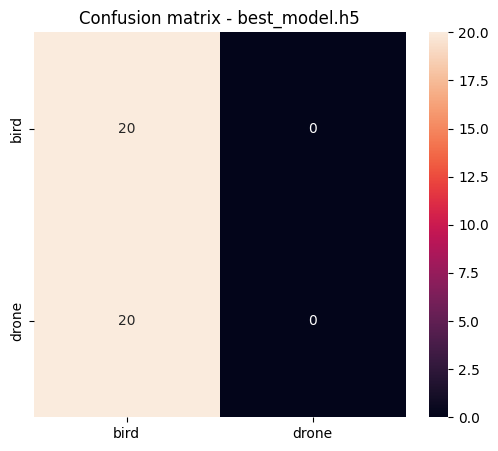

Classification report for best_model.h5:
              precision    recall  f1-score   support

        bird       0.50      1.00      0.67        20
       drone       0.00      0.00      0.00        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

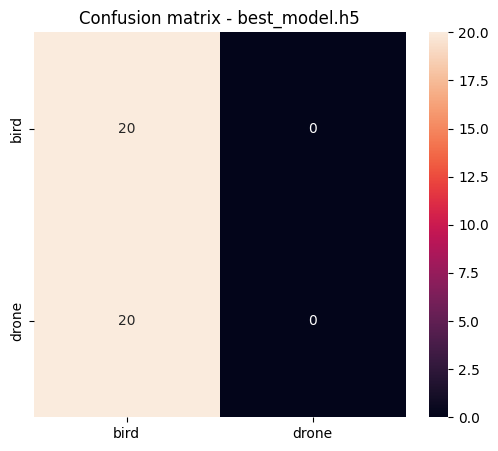

In [5]:
def evaluate_model(model_path, ds):
    model = tf.keras.models.load_model(model_path)
    y_true = []
    y_pred = []
    y_scores = []

    # Use an explicit iterator so we can catch/read errors on a per-batch basis and skip problematic files
    iterator = iter(ds)
    while True:
        try:
            batch = next(iterator)
        except StopIteration:
            break
        except (tf.errors.NotFoundError, tf.errors.InvalidArgumentError, OSError) as e:
            # Skip batches that fail due to missing/corrupt files and continue
            print(f"Warning: skipping a batch while iterating dataset due to error: {e}")
            continue

        try:
            x, y = batch
            preds = model.predict(x, verbose=0)
        except (tf.errors.NotFoundError, tf.errors.InvalidArgumentError, OSError) as e:
            # If prediction fails because reading a file in the batch failed, skip this batch
            print(f"Warning: skipping a batch during prediction due to error: {e}")
            continue

        y_true.extend(y.numpy().tolist())
        y_pred.extend(np.argmax(preds, axis=1).tolist())
        y_scores.extend(preds.tolist())

    print(f"Classification report for {model_path.name}:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion matrix - {model_path.name}")
    plt.show()
    return y_true, y_pred, np.array(y_scores)

y_true_c, y_pred_c, y_scores_c = evaluate_model(MODELS_CUSTOM, test_ds)
y_true_t, y_pred_t, y_scores_t = evaluate_model(MODELS_TL, test_ds)


In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def summarise(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

summary = pd.DataFrame({
    "custom_cnn": summarise(y_true_c, y_pred_c),
    "transfer_learning": summarise(y_true_t, y_pred_t)
}).T

display(summary)
output_dir = PROJECT_DIR / "outputs" / "model_comparison"
output_dir.mkdir(parents=True, exist_ok=True)
summary.to_csv(output_dir / "comparison_table.csv", index=True)


,accuracy,precision,recall,f1
custom_cnn,0.5,0.25,0.5,0.333333
transfer_learning,0.5,0.25,0.5,0.333333
